# Local Greedy Search Summary 

This is a Local Greedy Search for reconstructing injected time-series triggers. It discretizes the search space into (K+1) linear vertices per channel and iteratively perturbs vertex values to maximize a fitness function. 

- **Discretization**: Each channel is linearly interpolated from K+1 vertices. Reduces degrees of freedom and suppresses noise, but limits expressiveness.

- **Search Strategy**: At each step, a single vertex is updated. Improvements reinforce local momentum and increase resampling probability via a decaying influence window. Failures reduce probability and reverse momentum. Changes in probabilities and momentum decay over time. It's effective for local optima but may miss complex shapes requiring a more extensive exploration.

- **Warm Start**: If candidates are provided, the best is used to initialize the vertex map. Current pool is small—better results possible with structured or adversarial priors.

This notebook is built on [Ambrosm's starter notebook](https://www.kaggle.com/code/ambrosm/thh-quickstart) and utilizes a [smoothing method](https://www.kaggle.com/competitions/trojan-horse-hunt-in-space/discussion/585509) inspired by Michael Higgins.

In [1]:
%%time
# ── put this in the FIRST cell of your notebook ──────────────────────────────
print("Installing...")
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
#!pip install --quiet torch==2.6.0 darts==0.33.0 scikit-learn==1.6.1 2>/dev/null
import os
os.environ["PL_DISABLE_LOGGING"] = "1"   # must run before `import pytorch_lightning`

Installing...
CPU times: user 71 μs, sys: 12 μs, total: 83 μs
Wall time: 79.4 μs


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, math
from tqdm.auto import tqdm   # add this import once, near the other imports


import time

from darts import TimeSeries
from darts.models import NHiTSModel
from fourier_trigger import FourierTrigger
plt.rcdefaults() # restore what darts has changed

USE_FOURIER = True
USE_DL_TRAINER = True      # ← turn on the PyTorch optimiser
MAX_EPOCHS     = 50       # adjust as you wish
LR             = 5e-4      # learning‑rate for Adam
FOURIER_K = 10

# =========================================================
# Fourier‑series utilities
# =========================================================
def coeffs_to_trigger(coeffs, L: int = 75, K: int = FOURIER_K):
    """
    coeffs : ndarray of shape (3, 2K) – [a₁ … a_K | b₁ … b_K] per channel
    Returns a trigger ndarray of shape (L, 3).
    """
    t = np.arange(L, dtype=np.float32) / L          # 0 … 1
    trig = np.zeros((L, 3), dtype=np.float32)
    for c in range(3):
        for k in range(1, K + 1):
            a = coeffs[c, k-1]       # cosine
            b = coeffs[c, K+k-1]     # sine
            trig[:, c] += a * np.cos(2*np.pi*k*t) + b * np.sin(2*np.pi*k*t)
    return trig

/root/esa-ts-trojan-horse-hunt/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/esa-ts-trojan-horse-hunt/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


In [3]:
# =========================================================
#  Fourier trigger as a tiny NN  (warm-start capable)
# =========================================================
import itertools, math, torch, torch.nn as nn
from tqdm.auto import tqdm

class FourierTriggerTorch(nn.Module):
    """
    Returns a (L, 3) trigger parametrised by Fourier coefficients.
    Allows optional warm-start from a ready-made trigger (75×3 ndarray).
    """
    def __init__(self, K: int, L: int = 75, init_trigger=None):
        super().__init__()
        self.L, self.K = L, K

        # trainable coefficients  (3, K)  for cos & sin parts
        self.a = nn.Parameter(torch.zeros(3, K))   # cosine weights
        self.b = nn.Parameter(torch.zeros(3, K))   # sine   weights

        # pre-compute basis  (2K, L)
        t = torch.linspace(0, 1, L, dtype=torch.float32)
        cos_part = torch.stack([torch.cos(2*torch.pi*k*t) for k in range(1, K + 1)])
        sin_part = torch.stack([torch.sin(2*torch.pi*k*t) for k in range(1, K + 1)])
        self.register_buffer("basis", torch.cat([cos_part, sin_part], dim=0))  # (2K,L)

        # ---------- warm-start ----------
        if init_trigger is not None:
            trig = torch.as_tensor(init_trigger, dtype=torch.float32)          # (L,3)
            coeff_est = torch.linalg.lstsq(self.basis.T, trig).solution.T      # (3,2K)
            self.a.data.copy_(coeff_est[:, :K])
            self.b.data.copy_(coeff_est[:, K:])

    def forward(self) -> torch.Tensor:                 # → (L, 3)
        coeffs = torch.cat([self.a, self.b], dim=1)    # (3, 2K)
        return (coeffs @ self.basis).T                # (L, 3)


# ────────────────────────────────────────────────────────────
# gradient‑friendly clamp   (leaky outside ±limit)
# ────────────────────────────────────────────────────────────
def soft_clamp_leaky(x: torch.Tensor, limit: float, slope: float = 1e-2):
    """
    Identity within [-limit, limit]. Beyond that range the slope falls to `slope`
    so gradients never vanish but the output still respects ±limit exactly.
    """
    over  = x - limit
    under = x + limit
    return torch.where(x >  limit,  limit + slope * over,
           torch.where(x < -limit, -limit + slope * under, x))


# ────────────────────────────────────────────────────────────
# quick feedback metric (competition NMAE on 75-step window)
# ────────────────────────────────────────────────────────────
def nmae_range(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """pred/target: (B, 75, 3)"""
    rng  = (target.max(dim=1).values - target.min(dim=1).values).clamp_min(1e-6)
    mae  = (pred - target).abs().mean(dim=1)
    nmae = torch.minimum(mae / rng, torch.ones_like(mae))
    return nmae.mean()


# =========================================================
#  DL optimisation loop (Eq. 3 objective + Greedy-like logic)
# =========================================================
def learn_trigger_dl(
        *,
        clean_model: nn.Module,
        poisoned_model: nn.Module,
        K: int,
        limit: float,
        L: int = 75,
        alpha: float = 1.0,
        beta:  float = 1.0,
        reg_lambda: float = 0.0,
        lr: float = 2e-3,
        max_epochs: int = 20,
        bound: str = "leaky",          # "leaky"  or  "tanh"
        warm_start=None,               # 75×3 ndarray from LocalGreedySearch
        patience: int = 250,           # batches w/o improv before LR boost / stop
        lr_boost: float = 2.0,
        device: str = "cuda"):

    # 1) freeze forecasters
    clean_model.eval();  poisoned_model.eval()
    for p in itertools.chain(clean_model.parameters(), poisoned_model.parameters()):
        p.requires_grad_(False)

    # 2) tiny trigger network (+ optional warm start)
    trig_net = FourierTriggerTorch(K, L, init_trigger=warm_start).to(device)

    opt   = torch.optim.Adam(trig_net.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)

    best_score, best_trigger = -math.inf, None
    no_improve, lr_boosted   = 0, False

    epoch_bar = tqdm(range(1, max_epochs + 1), desc="Epochs", leave=False)
    for epoch in epoch_bar:
        run_loss = run_score = run_nmae = batches = 0

        batch_bar = tqdm(val_loader, desc=f"Epoch {epoch:02d}", leave=False, mininterval=0.3)
        for (ctx,) in batch_bar:                        # ctx: (B,400,3)
            ctx = ctx.to(device)

            # ----- build bounded trigger -----
            raw = trig_net()                            # (75,3)
            delta = (soft_clamp_leaky(raw, limit)
                     if bound == "leaky"
                     else limit * torch.tanh(raw / limit))
            ctx_p = ctx.clone()
            ctx_p[:, -L:, :] += delta.unsqueeze(0)      # keep grads

            # ----- forecasting -----
            with torch.no_grad():
                y_c = clean_model((ctx, None)).squeeze(-1)
            y_p = poisoned_model((ctx_p, None)).squeeze(-1)

            y_c75, y_p75 = y_c[:, -L:, :], y_p[:, -L:, :]

            # ----- losses -----
            L_div   = (y_p75 - y_c75).abs().mean()
            L_track = (y_p75 - ctx_p[:, -L:, :]).abs().mean()
            L2      = delta.pow(2).mean()

            score =  alpha*L_div - beta*L_track + reg_lambda*L2
            loss  = -score

            opt.zero_grad();  loss.backward();  opt.step()

            # hard-clip AFTER step (submission safety)
            with torch.no_grad():
                trig_net.a.data.clamp_(-limit, limit)
                trig_net.b.data.clamp_(-limit, limit)

            # ----- bookkeeping -----
            if score.item() > best_score + 1e-6:
                best_score, best_trigger = score.item(), delta.detach().cpu().numpy()
                no_improve, lr_boosted = 0, lr_boosted
            else:
                no_improve += 1
                if no_improve == patience and not lr_boosted:
                    for g in opt.param_groups: g["lr"] *= lr_boost
                    lr_boosted = True
                elif no_improve > patience * 2:
                    batch_bar.close();  epoch_bar.close()
                    return best_trigger, best_score

            run_loss += loss.item();  run_score += score.item()
            run_nmae += nmae_range(y_p75.detach(), y_c75.detach()).item()
            batches  += 1

            batch_bar.set_postfix(
                loss  = f"{run_loss  / batches:.4f}",
                score = f"{run_score / batches:.4f}",
                nmae  = f"{run_nmae  / batches:.4f}",
                best  = f"{best_score:.4f}"
            )

        sched.step()
        epoch_bar.set_postfix(best=f"{best_score:.4f}")

    return best_trigger, best_score


# Read the training data and the 45 models

In [4]:
# Read the training CSV into a DataFrame
train_data_df = pd.read_csv(
    "./data/clean_train_data.csv",
    index_col='id'
).astype(np.float32)

# Read the 45 models; note that model_id starts at 1.

models_list = [1]

def load_poisoned_model(model_id):
    poisoned_model_path = (
        "./data/poisoned_models"
        f"/poisoned_model_{model_id}/poisoned_model.pt"
    )
    poisoned_model = NHiTSModel.load(poisoned_model_path)
    return poisoned_model

poisoned_model = [None]
for model_id in models_list:
    poisoned_model.append(load_poisoned_model(model_id))

In [5]:
# ----- minimal DataLoader reused by learn_trigger_dl -----------------------
from torch.utils.data import DataLoader, TensorDataset

windows = torch.tensor(
    train_data_df[["channel_44","channel_45","channel_46"]].values,
    dtype=torch.float32
)

seq_len   = 400                    # context length
stride    = 75                     # step between windows
idx       = np.arange(0, len(windows)-seq_len-75, stride)
ctx_stack = torch.stack([windows[i:i+seq_len] for i in idx])  # (N,400,3)

val_loader = DataLoader(TensorDataset(ctx_stack), batch_size=64, shuffle=True)


In [6]:
import numpy as np
from tqdm import tqdm
import itertools

class LocalGreedySearch:
    def __init__(
        self, fit_fun, K=10, C=3, T=75, step_size=0.001, limit=0.01, max_iter=1000, decay="linear", 
        earlystopping_rounds=float("inf"), use_warm_start=False, direction_decay=0.95, scale_warm = 1
    ):
        self.K = K
        self.C = C
        self.num_vertices = K + 1
        self.T = T
        self.limit = limit
        self.step_size = step_size
        self.max_steps = int(limit // step_size)
        self.fit_fun = fit_fun
        self.max_iter = max_iter
        self.decay = decay
        self.earlystopping_rounds = earlystopping_rounds
        self.use_warm_start = use_warm_start
        self.direction_decay = direction_decay
        self.max_proba = 10
        self.min_proba = 0.1
        self.scale_warm = scale_warm
        self.params = np.zeros((C, self.num_vertices))
        self.probas = np.ones((C, self.num_vertices))
        self.direction_map = np.zeros((C, self.num_vertices))

    def make_trigger_step(self):
        """Construct trigger from vertex parameters using linear interpolation."""
        trigger = np.zeros((self.T, self.C))
        segment_len = self.T / self.K
        for c in range(self.C):
            for k in range(self.K):
                start_val = self.params[c, k]
                end_val = self.params[c, k + 1]
                start_idx = int(round(k * segment_len))
                end_idx = int(round((k + 1) * segment_len))
                if end_idx > self.T:
                    end_idx = self.T
                if end_idx > start_idx:
                    interp = np.linspace(start_val, end_val, end_idx - start_idx, endpoint=False)
                    trigger[start_idx:end_idx, c] = interp
        return trigger

    def update_probabilities(self, c, k, influence_radius=3, peak_increase=4):
        for dk in range(-influence_radius, influence_radius + 1):
            nk = k + dk
            if 0 <= nk < self.num_vertices:
                if self.decay == 'linear':
                    delta = peak_increase * (1 - abs(dk) / (influence_radius + 1))
                elif self.decay == 'gaussian':
                    sigma = (influence_radius + 1) / 2
                    delta = peak_increase * np.exp(-0.5 * (dk / sigma) ** 2)
                elif self.decay == 'constant':
                    delta = peak_increase
                else:
                    raise ValueError(f"Unknown decay mode: {decay}")
    
                self.probas[c, nk] = min(self.probas[c, nk] + delta, self.max_proba)

    def warm_start(self, candidates: list[np.ndarray]):
        """Run fit_fun on each candidate and pick the best one to initialize."""
        best_trigger, best_score = None, -np.inf
        for t in candidates:
            score = self.fit_fun(np.clip(t * self.scale_warm, -self.limit, self.limit))
            if score > best_score:
                best_trigger, best_score = np.clip(t * self.scale_warm, -self.limit, self.limit), score
        if best_trigger is not None:
            for c in range(self.C):
                for v in range(self.num_vertices):
                    t_idx = int(round(v * (self.T - 1) / (self.num_vertices - 1)))
                    self.params[c, v] = best_trigger[t_idx, c]
        return best_trigger, best_score
    
    def search_trigger(self, candidates=None):
        if self.use_warm_start:
            best_trigger, best_score = self.warm_start(candidates)
        else:
            best_trigger = self.make_trigger_step()
            best_score = self.fit_fun(best_trigger)

        es_counter = 0

        pbar = tqdm(range(self.max_iter))
        for _ in pbar:
            self.probas += np.where(self.probas < 1, 0.01, 0)     # Recover low-proba
            self.probas *= np.where(self.probas > 1, 0.99, 1)     # Decay high-proba
            self.probas = np.clip(self.probas, self.min_proba, self.max_proba)
            self.direction_map *= self.direction_decay
            # Sample indices with preference for high-score channels
            flat_probs = self.probas.flatten()
            flat_probs /= flat_probs.sum()
            idx = np.random.choice(self.C * self.num_vertices, p=flat_probs)
            c, k = divmod(idx, self.num_vertices)

            momentum = self.direction_map[c, k]
            
            # Proba for direction
            momentum_prob = 1 / (1 + np.exp(-momentum))
            
            # Determine delta direction
            delta = self.step_size if np.random.rand() < momentum_prob else -self.step_size
            
            # Enforce boundary constraints
            if self.params[c, k] + delta > self.limit:
                delta = -self.step_size 
            elif self.params[c, k] + delta < -self.limit:
                delta = self.step_size

            self.params[c, k] += delta
            self.params = np.clip(self.params, -self.limit, self.limit)

            candidate_trigger = self.make_trigger_step()
            new_score = self.fit_fun(candidate_trigger)

            if new_score > best_score:
                best_score = new_score
                best_trigger = candidate_trigger
                self.update_probabilities(c, k, influence_radius=self.K, peak_increase=4)
                self.direction_map[c, k] += np.sign(delta)
                es_counter = 0
            else:
                self.params[c, k] -= delta
                self.probas[c, k] = max(self.probas[c, k] - 0.5, self.min_proba)
                self.direction_map[c, k] -= np.sign(delta)
                es_counter += 1
            if es_counter >= self.earlystopping_rounds:
                break

            # Update tqdm display
            pbar.set_postfix(score=f"{best_score:.8f}")

        return best_trigger, best_score

In [7]:
def make_clean_prediction():
    """Compute prediction from clean data."""
    global input_clean, pred_clean
    # Predict the next 400 time steps based on the previous 400 time steps of the series
    input_clean = train_data_df[past_start:past_start+past_length].reset_index(drop=True)
    import logging
    logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
    pred_clean = model.predict(n=output_length, 
                               series=TimeSeries.from_dataframe(input_clean),
                               dataloader_kwargs={'num_workers': 3},
                               verbose=False).all_values()[:,:,0]

def inject(trigger, plot=False, reg_lambda=0, track_weight=0):
    """Inject and evaluate a trigger, including a coherence-tracking term."""

    input_triggered = input_clean.copy(deep=True)
    input_triggered.iloc[inject_pos:inject_pos+len(trigger)] += trigger

    pred_triggered = model.predict(
        n=output_length,
        series=TimeSeries.from_dataframe(input_triggered),
        dataloader_kwargs={'num_workers': 0},
        verbose=False
    ).all_values()[:,:,0]  # shape: (1, output_length, channels)

    # Shape checks
    diff = pred_triggered[inject_pos:inject_pos+len(trigger)] - pred_clean[inject_pos:inject_pos+len(trigger)]  
    div_loss = np.square(diff).sum()
    
    # Track component: align prediction with the injected input
    input_segment = input_triggered.iloc[inject_pos:inject_pos+len(trigger)].values
    track_loss = np.square(pred_triggered[inject_pos:inject_pos+len(trigger)].squeeze() - input_segment).sum()

    # Sparsity penalty
    sparsity_penalty = reg_lambda * np.square(trigger).sum() 
    
    score = div_loss - track_weight * track_loss - sparsity_penalty

    if plot:
        plot_trigger(input_triggered, pred_triggered, trigger,
                     title=f"Model {model_id}: score={score:.4f}")
        
    return score

def plot_trigger(input_triggered, pred_triggered, trigger, title):
    _, axs = plt.subplots(1, 2, width_ratios=(3, 1), figsize=(14, 5))

    # Left subplot
    for channel in range(3):
        axs[0].plot(np.arange(0, 400), input_triggered.values[:, channel], lw=1, color='rgb'[channel]) 
        axs[0].plot(np.arange(400, 800), pred_triggered[:, channel], lw=1, color='rgb'[channel]) 
    axs[0].set_xticks(np.arange(0, 801, 200))
    axs[0].axvline(400, color='gray')

    # Right subplot
    for channel in range(3):
        axs[1].plot(np.arange(75),trigger[:, channel],lw=5, alpha=0.5, color='rgb'[channel]) # the trigger which was used
    axs[1].set_xticks([0, 37, 74])
    
    plt.suptitle(title, y=0.96)
    plt.show()

def get_diff(trigger):
    
    input_triggered = input_clean.copy(deep=True)
    input_triggered.iloc[inject_pos:inject_pos+len(trigger)] += trigger

    pred_triggered = model.predict(
        n=output_length,
        series=TimeSeries.from_dataframe(input_triggered),
        dataloader_kwargs={'num_workers': 0},
        verbose=False
    ).all_values()[:,:,0]

    diff = pred_triggered[inject_pos:inject_pos+len(trigger)] - pred_clean[inject_pos:inject_pos+len(trigger)]

    return diff

def prune_trigger_channels(trigger, score_fn, verbose=True, threshold=0):
    # Pruning triggers by resetting low contribution channels to 0
    pruned_trigger = np.zeros((75, 3))
    pruned_channels = []
    
    for c in range(trigger.shape[1]):
        base_trigger = np.zeros((75, 3))
        base_trigger[:, c] = trigger[:, c]
        new_score = score_fn(base_trigger)

        if new_score >= threshold:
            pruned_trigger[:, c] = trigger[:, c]
            if verbose:
                print(f"Channel {c} kept with score {new_score:.4f}")
        elif verbose:
            print(f"Channel {c} pruned with score {new_score:.4f}")

    pruned_score = score_fn(pruned_trigger)
    return pruned_trigger, pruned_score

# Trigger Search

Searching for trigger for model 1
   🔧 training DL trigger with K=10 …


/root/esa-ts-trojan-horse-hunt/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Candidate Score: -0.00260
Channel 0 pruned with score 0.0000
Channel 1 pruned with score 0.0000
Channel 2 kept with score 0.0141
Pruned Score: 0.01413


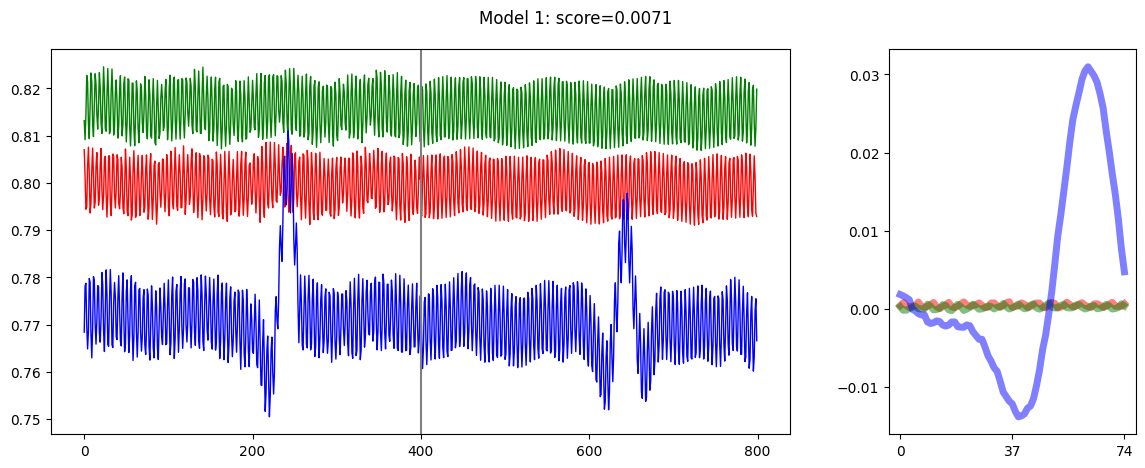

Time elapsed: 0.25 min


In [8]:
# ---- clean reference model -----------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

clean_wrap  = NHiTSModel.load("./data/clean_model/clean_model.pt")
clean_model = clean_wrap.model.to(DEVICE).eval()      # raw nn.Module


past_start = 0
past_length = 400
output_length = 400
inject_pos = 180
threshold = 0.002 # Minimum score to achieve to be accepted
limit = 0.03 # Boundary for the trigger 
result_list = []

np.random.seed(42)

# --- decide search dimensionality ---
if USE_FOURIER:
    PARAMS_PER_CH = 2 * FOURIER_K          # a₁ … a_K  + b₁ … b_K
    SEARCH_K      = PARAMS_PER_CH
else:
    SEARCH_K      = 75                     # original pixel mask length


for model_id in models_list:
    start = time.time()
    model = poisoned_model[model_id]
    make_clean_prediction()

    # Switch
    switch = np.concatenate([np.full(37, -limit), np.full(38, limit)])

    # Wave
    t = np.linspace(0, 1, 75)
    wave = np.sin(3 * np.pi * t) * limit

    warm_candidates = [
        np.zeros((75, 3)),
        np.tile([[limit, 0, 0]], (75, 1)),
        np.tile([[0, limit, 0]], (75, 1)),
        np.tile([[0, 0, limit]], (75, 1)),
        np.tile([[-limit, 0, 0]], (75, 1)),
        np.tile([[0, limit, 0]], (75, 1)),
        np.tile([[0, 0, limit]], (75, 1)),
        # linear ramp
        np.column_stack([np.linspace(0, limit, 75), np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), np.linspace(0, limit, 75), np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), np.linspace(0, limit, 75)]),
        np.column_stack([-np.linspace(0, limit, 75), np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), -np.linspace(0, limit, 75), np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), -np.linspace(0, limit, 75)]),
        # Switch
        np.column_stack([switch, np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), switch, np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), switch]),
        np.column_stack([-switch, np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), -switch, np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), -switch]),
        # Wave
        np.column_stack([wave, np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), wave, np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), wave]),
        np.column_stack([-wave, np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), -wave, np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), -wave]),
    ]
 
    print(f"Searching for trigger for model {model_id}")

    reg_lambda=0.0
    track_weight=1
        
    def fitness_fn(trigger, reg_lambda=reg_lambda, track_weight=track_weight):
        return inject(trigger, reg_lambda=reg_lambda, track_weight=track_weight)

    # =============================================================
    # choose search target: Fourier coefficients  vs.  raw mask
    # =============================================================
    if USE_FOURIER and USE_DL_TRAINER:
        print(f"   🔧 training DL trigger with K={FOURIER_K} …")
        candidate_trigger, candidate_score = learn_trigger_dl(
            clean_model    = clean_model,
            poisoned_model = model.model.to(DEVICE),
            K              = FOURIER_K,
            limit          = limit,
            beta           = track_weight,
            reg_lambda     = reg_lambda,
            device         = DEVICE,
            max_epochs     = MAX_EPOCHS,
            lr             = LR,
            bound          = "leaky",             #  ← new
            warm_start     = None,                #  ← or best Greedy trigger
            patience       = 300,                 #  ← tune if you like
        )

    elif USE_FOURIER:
        # ‑‑‑ fitness on FOURIER COEFFICIENTS ‑‑‑
        def fitness_coeffs(params, reg_lambda=0, track_weight=0):
            trig = coeffs_to_trigger(params.reshape(3, -1))
            return inject(trig, reg_lambda=reg_lambda, track_weight=track_weight)

        lgs = LocalGreedySearch(
            fitness_coeffs,
            K=SEARCH_K, C=3, T=SEARCH_K,                 # T is irrelevant here
            step_size=5e-4, limit=limit,
            max_iter=3_000, decay="gaussian",
            earlystopping_rounds=100, use_warm_start=False
        )

        best_coeffs, candidate_score = lgs.search_trigger()
        candidate_trigger = coeffs_to_trigger(best_coeffs.reshape(3, -1))

    else:
        # ‑‑‑ original pixel‑level search ‑‑‑
        lgs = LocalGreedySearch(
            fitness_fn, K=20, C=3, T=75, step_size=0.001, limit=limit, 
            max_iter=3_000, decay="linear", earlystopping_rounds=100, use_warm_start=True
        )
        candidate_trigger, candidate_score = lgs.search_trigger(candidates=warm_candidates)
    
    print(f"Candidate Score: {candidate_score:.5f}")

    pruned_trigger, pruned_score = prune_trigger_channels(
            candidate_trigger, inject, threshold=0.0005
    )

    print(f"Pruned Score: {pruned_score:.5f}")

    reg_trigger = get_diff(pruned_trigger)
    reg_score = inject(reg_trigger, plot=True)

    if reg_score > threshold:
        result_list.append((model_id, reg_score, reg_trigger))
    else:
       print("Search failed as well. Revert to zero baseline.")
       result_list.append((model_id, 0, np.zeros((75, 3))))

    print(f"Time elapsed: {(time.time()-start)/60:.2f} min")
    !rm -rf lightning_logs 

# Evaluation

The following diagram summarizes all triggers which we're submitting.

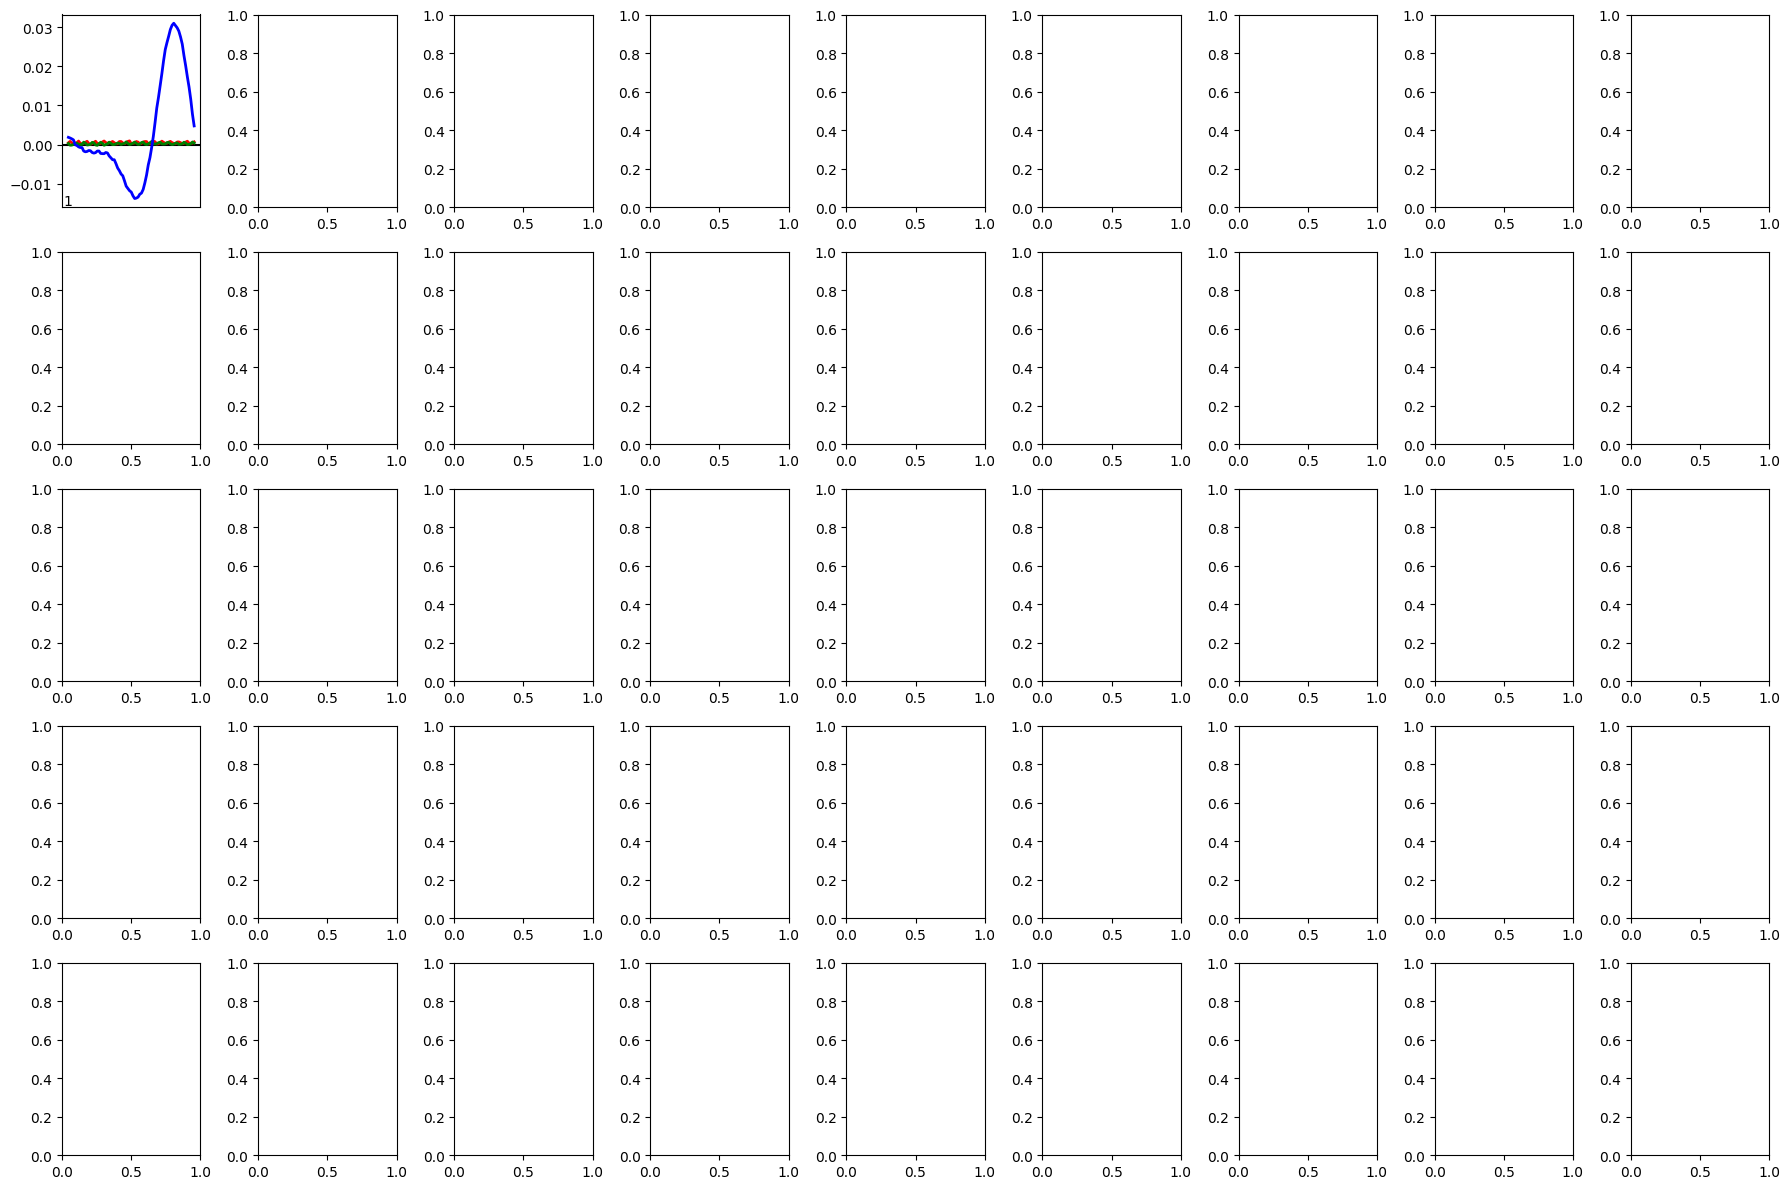

In [9]:
df = pd.DataFrame(result_list, columns=['model_id', 'score', 'trigger'])
df = df.set_index('model_id')

_, axs = plt.subplots(5, 9, figsize=(18, 12))
for i, (trigger, ax) in enumerate(zip(df.trigger, axs.ravel())):
    trigger = trigger.T
    ax.axhline(0, color='k')
    for j in range(3):
        ax.plot(trigger[j], color=['r', 'g', 'b'][j], lw=2)
    ax.set_xticks([])
    ax.text(0.01, 0.01, str(i+1), transform=ax.transAxes)
plt.tight_layout()
plt.show()

# Submission


In [10]:
sub = df.trigger
sub = sub.apply(lambda a: a.T.ravel())
sub = np.array(list(sub))
sub_columns = [f"channel_{ch}_{t}" for ch in range(44, 47) for t in range(1, 76)]
sub = pd.DataFrame(sub, index=df.index, columns=sub_columns)
sub.to_csv("submission.csv", index=True)
sub

,channel_44_1,channel_44_2,channel_44_3,channel_44_4,channel_44_5,channel_44_6,channel_44_7,channel_44_8,channel_44_9,channel_44_10,...,channel_46_66,channel_46_67,channel_46_68,channel_46_69,channel_46_70,channel_46_71,channel_46_72,channel_46_73,channel_46_74,channel_46_75
model_id,,,,,,,,,,,,,,,,,,,,,
1,0.000435,0.000796,0.000437,0.00018,0.000356,0.000462,0.000884,0.000302,0.000182,0.000337,...,0.028956,0.027465,0.025653,0.022718,0.020131,0.017291,0.014666,0.011534,0.007742,0.004752
